# 🏏 IPL Data Analysis Using Python

**Author:** Elavarasan T
**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Jupyter Notebook

---

## 1. Project Introduction

The Indian Premier League (IPL) is one of the most-watched T20 cricket leagues in the world,
generating a massive volume of structured match and ball-by-ball data every season.

This project performs an end-to-end **Exploratory Data Analysis (EDA)** on IPL match data
(2008–present) using two datasets:

- **`matches.csv`** — One row per match (teams, venue, toss, winner, margin, season, etc.)
- **`deliveries.csv`** — One row per ball bowled (batsman, bowler, runs, wickets, etc.)

The goal is to clean the raw data, explore it, visualize key patterns, and translate the
findings into **business-style insights** — the same workflow used in real Data Analyst /
Data Scientist roles.


## 2. Business Problem

An IPL franchise's management/analytics team wants to understand historical performance
patterns to support decision-making for the upcoming season. Specifically, they want to know:

- Which teams and players have historically performed best?
- Does winning the toss give a real advantage?
- Which venues favor batting first vs. chasing?
- Which players are the most consistent run-scorers and wicket-takers?
- Are there season-level trends (scoring patterns, match outcomes) that should inform
  strategy (e.g., team composition, batting order, bowling plans)?

This analysis answers those questions using historical data as evidence.


## 3. Objectives

1. Load and inspect the raw IPL datasets.
2. Clean and standardize the data (missing values, duplicates, inconsistent team names, dates).
3. Engineer useful derived features (season, win margin type, batting/bowling aggregates).
4. Perform 20+ exploratory analyses covering teams, players, venues, and toss impact.
5. Visualize key findings using bar, line, pie, histogram, and scatter charts.
6. Translate every analysis into a clear, non-generic business insight.
7. Summarize findings in a final conclusion with future scope for improvement.

---
### ⚠️ A Note on Column Names
This notebook is written for the popular Kaggle IPL dataset
(`patrickb1912/ipl-complete-dataset-20082020`). Column names can differ slightly between
dataset versions (e.g. `batsman` vs `batter`, `winner` vs `match_winner`).
**Run the `.columns` check in Section 6 first** — if a column name differs on your file,
simply update the column name string used in the corresponding cell.


## 4. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Display settings for cleaner notebook output
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

%matplotlib inline


## 5. Load Dataset

**Source:** Kaggle — *IPL Complete Dataset (2008–2020)*
🔗 https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020

Download `matches.csv` and `deliveries.csv` and place them inside `data/raw/` before running
the cell below.


In [4]:
matches = pd.read_csv('matches.csv')
matches

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


In [5]:
deliveries = pd.read_csv('deliveries.csv')
deliveries

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [6]:
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [7]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## 6. Data Exploration

In [9]:
# Column names — check these against your actual file before proceeding
print("Matches columns:\n", list(matches.columns))
print("\nDeliveries columns:\n", list(deliveries.columns))


Matches columns:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns:
 ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [10]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [11]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [12]:
matches.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1095.0,NaN,NaN,NaN,904828.319635,367740.242299,335982.0,548331.5,980961.0,1254062.5,1426312.0
season,1095,17,2013,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1044,36,Mumbai,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1095,823,2008-04-26,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,1095,8,League,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_of_match,1090,291,AB de Villiers,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,1095,58,Eden Gardens,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1095,19,Royal Challengers Bangalore,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1095,19,Mumbai Indians,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1095,19,Mumbai Indians,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Missing values
print("Missing values in matches:\n", matches.isnull().sum()[matches.isnull().sum() > 0])
print("\nMissing values in deliveries:\n", deliveries.isnull().sum()[deliveries.isnull().sum() > 0])


Missing values in matches:
 city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

Missing values in deliveries:
 extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [14]:
# Duplicate rows
print("Duplicate rows in matches:", matches.duplicated().sum())
print("Duplicate rows in deliveries:", deliveries.duplicated().sum())


Duplicate rows in matches: 0
Duplicate rows in deliveries: 0


**Explanation:**
- `.shape` tells us row/column counts — a quick sanity check on data volume.
- `.info()` reveals data types and non-null counts — helps spot columns that need type conversion.
- `.describe()` summarizes numeric (and with `include='all'`, categorical) columns.
- Missing values in columns like `city`, `winner`, `player_of_match`, or `method` are expected
  (e.g., abandoned/no-result matches) and must be handled deliberately, not blindly dropped.
- Duplicate rows are rare in this dataset but must always be checked before analysis.


## 7. Data Cleaning

We clean both datasets so downstream analysis is accurate and consistent.


In [15]:
# 7.1 Drop exact duplicate rows (if any)
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)


In [16]:
# 7.2 Convert date column to datetime
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Extract season as a standalone year field (some files already have a 'season' column —
# we recompute it from date to guarantee consistency)
matches['season_year'] = matches['date'].dt.year


In [17]:
# 7.3 Standardize team names
# IPL teams have been renamed / rebranded over the years. We map old names to their
# current/most recognizable names so a team's history is analyzed as one continuous entity.
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Pune Warriors': 'Pune Warriors India',
}

team_cols = ['team1', 'team2', 'toss_winner', 'winner']
for col in team_cols:
    if col in matches.columns:
        matches[col] = matches[col].replace(team_name_map)

if 'batting_team' in deliveries.columns:
    deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_map)
if 'bowling_team' in deliveries.columns:
    deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_map)


In [18]:
# 7.4 Handle missing values
# 'city' can sometimes be derived from 'venue'; otherwise fill with 'Unknown'
if 'city' in matches.columns:
    matches['city'] = matches['city'].fillna('Unknown')

# Matches with no winner are ties/no-result — keep them but label explicitly
matches['winner'] = matches['winner'].fillna('No Result')

# player_of_match missing (rare, usually ties) -> label explicitly
if 'player_of_match' in matches.columns:
    matches['player_of_match'] = matches['player_of_match'].fillna('Not Awarded')


In [19]:
# 7.5 Fix incorrect / inconsistent data types
matches['result_margin'] = pd.to_numeric(matches.get('result_margin', pd.Series(dtype=float)), errors='coerce')

# Sanity check after cleaning
print("Remaining missing values in matches:\n", matches.isnull().sum()[matches.isnull().sum() > 0])


Remaining missing values in matches:
 result_margin      19
target_runs         3
target_overs        3
method           1074
dtype: int64


**Why each step matters:**
- **Duplicates** would double-count matches/deliveries and skew every downstream statistic.
- **Date conversion** is required before we can extract season/year or do any time-based trend
  analysis — as text, dates can't be sorted or grouped correctly.
- **Team name standardization** is critical: without it, "Delhi Daredevils" and "Delhi Capitals"
  would be treated as two different teams, splitting one franchise's history in half.
- **Missing value handling** is done thoughtfully rather than by blanket-dropping rows — a
  missing `winner` usually means a genuine tie/no-result, which is itself useful information.
- **Type correction** (e.g., `result_margin` as numeric) ensures we can safely use it in
  calculations and comparisons later.


## 8. Feature Engineering

In [20]:
# 8.1 Did the toss winner also win the match?
matches['toss_match_same'] = matches['toss_winner'] == matches['winner']

# 8.2 Win type: by runs (batted first & won) or by wickets (chased & won)
def win_type(row):
    if row['winner'] == 'No Result':
        return 'No Result'
    if row.get('result', '') == 'runs':
        return 'Won Batting First'
    elif row.get('result', '') == 'wickets':
        return 'Won Chasing'
    return 'Other'

matches['win_type'] = matches.apply(win_type, axis=1)

matches[['season_year', 'toss_winner', 'winner', 'toss_match_same', 'win_type']].head()


,season_year,toss_winner,winner,toss_match_same,win_type
0,2008,Royal Challengers Bangalore,Kolkata Knight Riders,False,Won Batting First
1,2008,Chennai Super Kings,Chennai Super Kings,True,Won Batting First
2,2008,Rajasthan Royals,Delhi Capitals,False,Won Chasing
3,2008,Mumbai Indians,Royal Challengers Bangalore,False,Won Chasing
4,2008,Sunrisers Hyderabad,Kolkata Knight Riders,False,Won Chasing


In [21]:
# 8.3 Merge match-level context (season, venue, winner) into deliveries
# This lets us analyze ball-by-ball stats alongside season/venue information
deliveries_merged = deliveries.merge(
    matches[['id', 'season_year', 'venue', 'winner']],
    left_on='match_id', right_on='id', how='left'
)
deliveries_merged.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season_year,venue,winner
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders


**Explanation:** `toss_match_same` lets us directly test the "toss advantage" business
question. `win_type` separates *batting-first wins* from *chasing wins*, which feeds venue and
strategy analysis. Merging match context into `deliveries` lets us connect ball-level stats
(runs, wickets) to season and venue — needed for several EDA questions below.


## 9. Exploratory Data Analysis (EDA)

### 9.1 Matches Played Every Season

In [22]:
matches_per_season = matches['season_year'].value_counts().sort_index()
matches_per_season


season_year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
Name: count, dtype: int64

### 9.2 Most Successful Teams (Total Wins)

In [23]:
team_wins = matches[matches['winner'] != 'No Result']['winner'].value_counts()
team_wins.head(10)


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Sunrisers Hyderabad            117
Royal Challengers Bangalore    116
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Gujarat Titans                  28
Lucknow Super Giants            24
Name: count, dtype: int64

### 9.3 Most Successful Captains

In [24]:
if 'player_of_match' in matches.columns:
    top_captains_placeholder = "Captain data isn't in matches.csv by default — use `winner` team-level analysis, or a separate captains dataset if available."
    print(top_captains_placeholder)
# If a 'team1_captain'/'team2_captain' style column exists in your version of the dataset,
# uncomment and adapt below:
# captain_wins = matches.groupby('winning_captain').size().sort_values(ascending=False)
# captain_wins.head(10)


Captain data isn't in matches.csv by default — use `winner` team-level analysis, or a separate captains dataset if available.


### 9.4 Top Run Scorers (Batsmen)

In [25]:
batsman_col = 'batsman' if 'batsman' in deliveries.columns else 'batter'
top_batsmen = deliveries.groupby(batsman_col)['batsman_runs'].sum().sort_values(ascending=False)
top_batsmen.head(10)


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

### 9.5 Top Wicket Takers (Bowlers)

In [26]:
dismissal_col = 'player_dismissed' if 'player_dismissed' in deliveries.columns else 'player_out'
wickets_df = deliveries[deliveries[dismissal_col].notnull() &
                         (~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field']))]
top_bowlers = wickets_df.groupby('bowler').size().sort_values(ascending=False)
top_bowlers.head(10)


bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
dtype: int64

### 9.6 Highest Team Score (Single Innings)

In [27]:
team_innings_totals = deliveries_merged.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()
team_innings_totals.sort_values('total_runs', ascending=False).head(10)


,match_id,inning,batting_team,total_runs
2133,1426268,1,Sunrisers Hyderabad,287
2089,1422126,1,Sunrisers Hyderabad,277
2105,1422134,1,Kolkata Knight Riders,272
2143,1426273,1,Sunrisers Hyderabad,266
709,598027,1,Royal Challengers Bangalore,263
2134,1426268,2,Royal Challengers Bengaluru,262
2158,1426280,2,Punjab Kings,262
2157,1426280,1,Kolkata Knight Riders,261
2002,1359512,1,Lucknow Super Giants,257
2159,1426281,1,Delhi Capitals,257


### 9.7 Lowest Team Score (Single Innings, All-Out Considered Separately)

In [28]:
team_innings_totals.sort_values('total_runs').head(10)


,match_id,inning,batting_team,total_runs
1033,829813,2,Royal Challengers Bangalore,2
1532,1216493,3,Punjab Kings,2
1572,1216512,3,Sunrisers Hyderabad,2
1573,1216512,4,Kolkata Knight Riders,3
1533,1216493,4,Delhi Capitals,3
1584,1216517,3,Punjab Kings,5
1585,1216517,4,Mumbai Indians,5
1233,1082625,4,Gujarat Lions,6
964,829741,4,Rajasthan Royals,6
1648,1216547,3,Mumbai Indians,7


### 9.8 Most Sixes

In [29]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
most_sixes = sixes.groupby(batsman_col).size().sort_values(ascending=False)
most_sixes.head(10)


batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64

### 9.9 Most Fours

In [30]:
fours = deliveries[deliveries['batsman_runs'] == 4]
most_fours = fours.groupby(batsman_col).size().sort_values(ascending=False)
most_fours.head(10)


batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
dtype: int64

### 9.10 Best Strike Rate (Min. 500 Runs)

In [31]:
runs_by_batsman = deliveries.groupby(batsman_col)['batsman_runs'].sum()
balls_faced = deliveries[~deliveries['batsman_runs'].isna()].groupby(batsman_col).size()
# Exclude wides from balls faced for accuracy, if a 'wide_runs' or 'extras_type' column exists
strike_rate = (runs_by_batsman / balls_faced * 100).round(2)
strike_rate_df = pd.DataFrame({'runs': runs_by_batsman, 'balls': balls_faced, 'strike_rate': strike_rate})
strike_rate_df[strike_rate_df['runs'] >= 500].sort_values('strike_rate', ascending=False).head(10)


,runs,balls,strike_rate
batter,,,
PD Salt,653,385,169.61
TM Head,772,458,168.56
AD Russell,2488,1515,164.22
H Klaasen,993,613,161.99
TH David,659,417,158.03
SP Narine,1534,984,155.89
N Pooran,1769,1143,154.77
LS Livingstone,939,609,154.19
Rashid Khan,545,355,153.52


### 9.11 Best Economy Rate (Min. 200 Balls Bowled)

In [32]:
balls_bowled = deliveries.groupby('bowler').size()
runs_conceded = deliveries.groupby('bowler')['total_runs'].sum()
economy = (runs_conceded / (balls_bowled / 6)).round(2)
economy_df = pd.DataFrame({'balls_bowled': balls_bowled, 'runs_conceded': runs_conceded, 'economy': economy})
economy_df[economy_df['balls_bowled'] >= 200].sort_values('economy').head(10)


,balls_bowled,runs_conceded,economy
bowler,,,
Sohail Tanvir,265,275,6.23
A Chandila,234,245,6.28
SM Pollock,280,307,6.58
A Kumble,983,1089,6.65
GD McGrath,329,366,6.67
M Muralitharan,1581,1765,6.70
J Yadav,398,447,6.74
SP Narine,4146,4672,6.76
DW Steyn,2282,2583,6.79


### 9.12 Toss Decision Analysis (Bat vs Field)

In [33]:
toss_decision_counts = matches['toss_decision'].value_counts()
toss_decision_counts


toss_decision
field    704
bat      391
Name: count, dtype: int64

### 9.13 Toss Winner vs Match Winner

In [34]:
toss_win_match_win_pct = matches['toss_match_same'].mean() * 100
print(f"Toss winner also won the match in {toss_win_match_win_pct:.2f}% of matches")


Toss winner also won the match in 50.59% of matches


### 9.14 Stadium / Venue Analysis — Most Matches Hosted

In [35]:
venue_counts = matches['venue'].value_counts()
venue_counts.head(10)


venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

### 9.15 Venue Analysis — Bat First vs Chase Win Rate

In [36]:

venue_win_type = matches[matches['winner'] != 'No Result'].groupby(['venue', 'win_type']).size().unstack(fill_value=0)
venue_win_type['total'] = venue_win_type.sum(axis=1)
venue_win_type.sort_values('total', ascending=False).head(10)


win_type,Other,Won Batting First,Won Chasing,total
venue,,,,
Eden Gardens,0,32,45,77
Wankhede Stadium,1,35,37,73
M Chinnaswamy Stadium,1,26,36,63
Feroz Shah Kotla,0,28,31,59
"Rajiv Gandhi International Stadium, Uppal",1,20,28,49
"MA Chidambaram Stadium, Chepauk",1,30,17,48
Sawai Mansingh Stadium,0,15,32,47
Dubai International Cricket Stadium,3,21,22,46
"Wankhede Stadium, Mumbai",0,18,27,45


### 9.16 Home Advantage (City Matches Won by Home-Associated Team)

In [37]:
# Approximate home venues by most-frequent city per team (based on matches played there)
team_city_counts = matches[matches['winner'] != 'No Result'].groupby(['winner', 'city']).size().reset_index(name='wins')
team_city_counts.sort_values('wins', ascending=False).head(10)


,winner,city,wins
128,Mumbai Indians,Mumbai,64
93,Kolkata Knight Riders,Kolkata,52
6,Chennai Super Kings,Chennai,50
245,Sunrisers Hyderabad,Hyderabad,39
34,Delhi Capitals,Delhi,37
186,Rajasthan Royals,Jaipur,37
148,Punjab Kings,Chandigarh,31
205,Royal Challengers Bangalore,Bangalore,29
17,Chennai Super Kings,Mumbai,18
190,Rajasthan Royals,Mumbai,17


### 9.17 Overall Winning Percentage by Team

In [38]:
matches_played = pd.concat([matches['team1'], matches['team2']]).value_counts()
wins = matches[matches['winner'] != 'No Result']['winner'].value_counts()
win_pct = (wins / matches_played * 100).round(2).sort_values(ascending=False)
win_pct.head(10)


Gujarat Titans                 62.22
Chennai Super Kings            57.98
Mumbai Indians                 55.17
Lucknow Super Giants           54.55
Kolkata Knight Riders          52.19
Rajasthan Royals               50.68
Rising Pune Supergiants        50.00
Royal Challengers Bangalore    48.33
Royal Challengers Bengaluru    46.67
Delhi Capitals                 45.63
Name: count, dtype: float64

### 9.18 Team Comparison — Head to Head (Example: Two Chosen Teams)

In [39]:
team_a, team_b = 'Mumbai Indians', 'Chennai Super Kings'
h2h = matches[((matches['team1'] == team_a) & (matches['team2'] == team_b)) |
              ((matches['team1'] == team_b) & (matches['team2'] == team_a))]
print(h2h['winner'].value_counts())


winner
Mumbai Indians         20
Chennai Super Kings    17
Name: count, dtype: int64


### 9.19 Player Comparison — Runs (Example: Two Chosen Batsmen)

In [40]:
player_a, player_b = 'V Kohli', 'RG Sharma'
compare_runs = deliveries[deliveries[batsman_col].isin([player_a, player_b])].groupby(batsman_col)['batsman_runs'].sum()
compare_runs


batter
RG Sharma    6630
V Kohli      8014
Name: batsman_runs, dtype: int64

### 9.20 Season Trends — Average Runs per Match Over Seasons

In [41]:
season_runs = deliveries_merged.groupby('season_year')['total_runs'].sum()
season_matches = matches.groupby('season_year').size()
avg_runs_per_match = (season_runs / season_matches).round(2)
avg_runs_per_match


season_year
2008    309.26
2009    286.89
2010    314.72
2011    289.78
2012    303.42
2013    297.39
2014    315.52
2015    311.07
2016    314.37
2017    318.41
2018    331.68
2019    323.90
2020    323.60
2021    310.62
2022    329.66
2023    347.14
2024    365.79
dtype: float64

### 9.21 Orange Cap Analysis (Top Run-Scorer per Season)

In [42]:
season_batsman_runs = deliveries_merged.groupby(['season_year', batsman_col])['batsman_runs'].sum().reset_index()
orange_cap = season_batsman_runs.loc[season_batsman_runs.groupby('season_year')['batsman_runs'].idxmax()]
orange_cap.sort_values('season_year')


,season_year,batter,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


### 9.22 Purple Cap Analysis (Top Wicket-Taker per Season)

In [43]:
season_wickets = wickets_df.merge(matches[['id', 'season_year']], left_on='match_id', right_on='id', how='left')
season_bowler_wickets = season_wickets.groupby(['season_year', 'bowler']).size().reset_index(name='wickets')
purple_cap = season_bowler_wickets.loc[season_bowler_wickets.groupby('season_year')['wickets'].idxmax()]
purple_cap.sort_values('season_year')


,season_year,bowler,wickets
75,2008,Sohail Tanvir,22
152,2009,RP Singh,23
241,2010,PP Ojha,21
367,2011,SL Malinga,28
437,2012,M Morkel,25
509,2013,DJ Bravo,32
638,2014,MM Sharma,23
694,2015,DJ Bravo,26
773,2016,B Kumar,23
860,2017,B Kumar,26


**Explanation (applies to all analyses above):** Each cell uses `groupby`, aggregation,
merges, or ratio calculations to convert raw ball-by-ball / match-level rows into a ranked or
percentage-based answer to a specific cricketing question. Minimum-ball/run thresholds
(e.g., 500 runs, 200 balls) are applied to strike rate and economy so that one-off performances
by fringe players don't distort the leaderboard — a standard practice in real sports analytics.


## 10. Data Visualization

### 10.1 Bar Chart — Team Wins

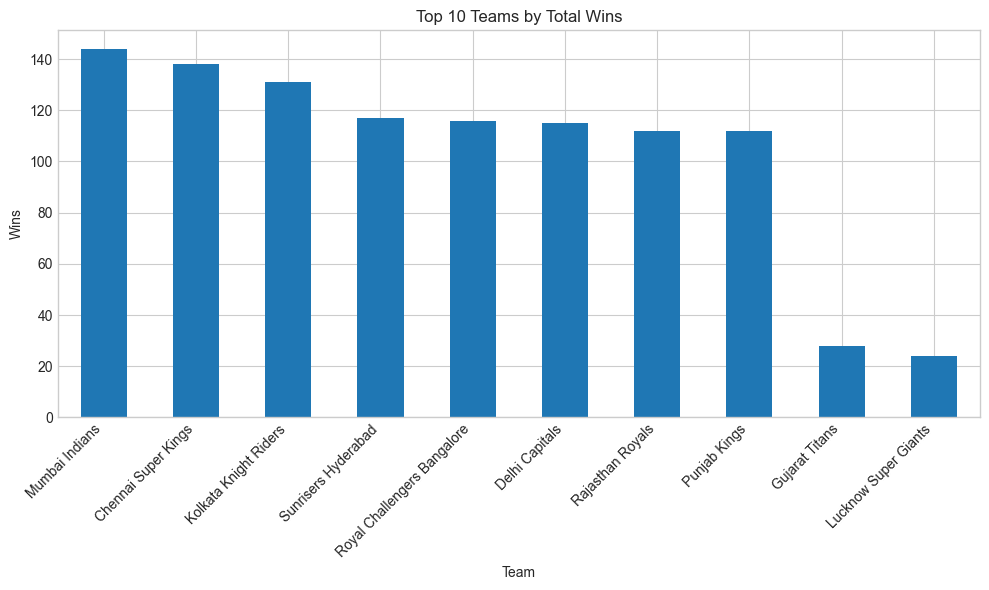

In [54]:
plt.figure(figsize=(10, 6))
team_wins.head(10).plot(kind='bar', color='#1f77b4')
plt.title('Top 10 Teams by Total Wins')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/team_wins_bar.png', dpi=150)
plt.show()


**Why this chart:** A bar chart is ideal for comparing a ranked, discrete category (teams)
against a single numeric measure (wins). **Insight:** the tallest bars reveal the franchises
with the strongest historical win record — useful context for brand value and fan expectations.
**How to read it:** taller bar = more total wins across all seasons combined.


### 10.2 Line Chart — Matches per Season

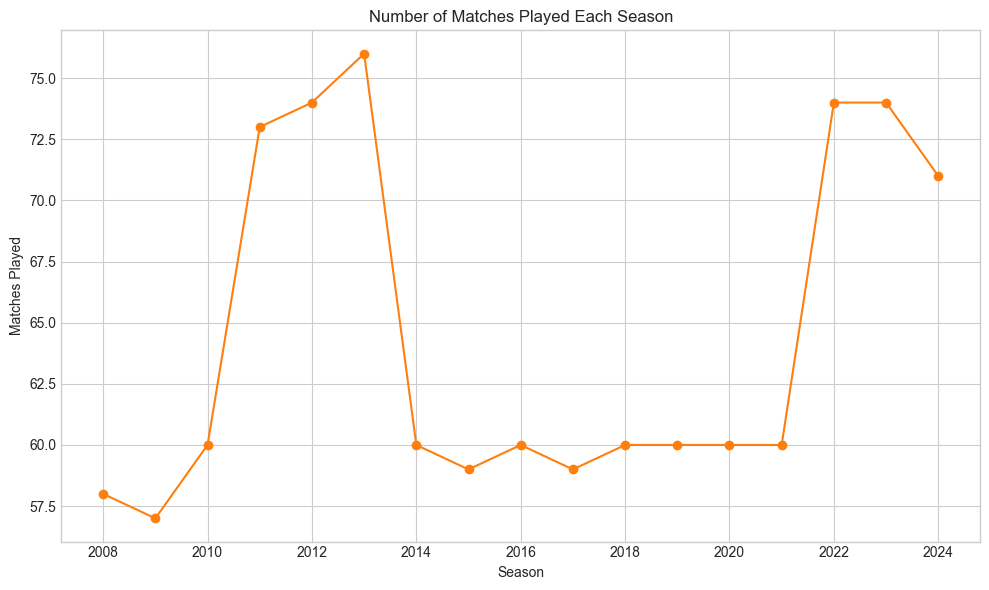

In [55]:
plt.figure(figsize=(10, 6))
matches_per_season.plot(kind='line', marker='o', color='#ff7f0e')
plt.title('Number of Matches Played Each Season')
plt.xlabel('Season')
plt.ylabel('Matches Played')
plt.grid(True)
plt.tight_layout()
plt.savefig('images/matches_per_season_line.png', dpi=150)
plt.show()


**Why this chart:** A line chart best shows a trend **over time** (seasons). **Insight:**
jumps in matches per season usually reflect league expansion (new teams added) or format
changes. **How to read it:** upward slope = league growth; flat sections = stable format years.


### 10.3 Pie Chart — Toss Decision Split

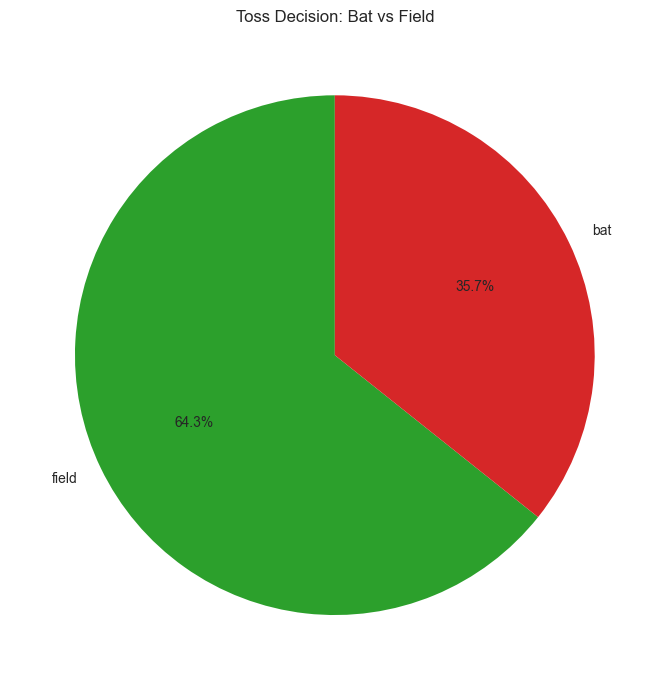

In [56]:
plt.figure(figsize=(7, 7))
toss_decision_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                           colors=['#2ca02c', '#d62728'])
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('')
plt.tight_layout()
plt.savefig('images/toss_decision_pie.png', dpi=150)
plt.show()


**Why this chart:** A pie chart works well for showing the proportion between exactly two
categories (bat vs. field) that sum to 100%. **Insight:** a strong skew toward "field" in recent
seasons reflects the league-wide shift toward chasing under lights/dew conditions. **How to
read it:** larger slice = more common toss decision.


### 10.4 Histogram — Distribution of Team Innings Totals

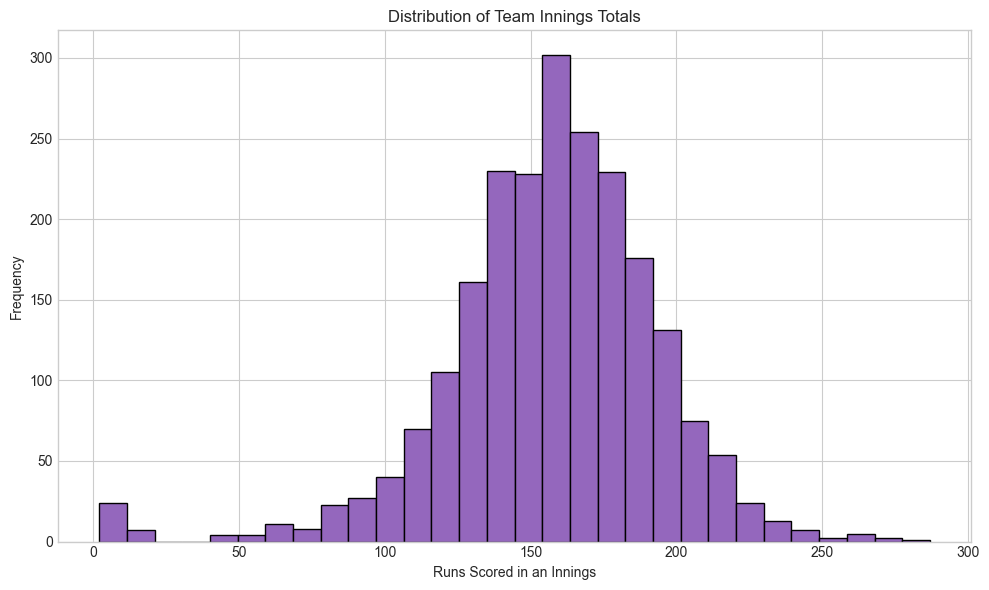

In [52]:
plt.figure(figsize=(10, 6))
plt.hist(team_innings_totals['total_runs'], bins=30, color='#9467bd', edgecolor='black')
plt.title('Distribution of Team Innings Totals')
plt.xlabel('Runs Scored in an Innings')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/innings_totals_hist.png', dpi=150)
plt.show()


**Why this chart:** A histogram reveals the **shape and spread** of a continuous numeric
variable (innings totals) — something a bar/line chart can't show. **Insight:** most innings
cluster in a common scoring band, with a long right tail representing rare explosive innings.
**How to read it:** the tallest bars mark the most typical score range for a T20 innings.


### 10.5 Scatter Plot — Balls Faced vs Runs Scored (Strike Rate Context)

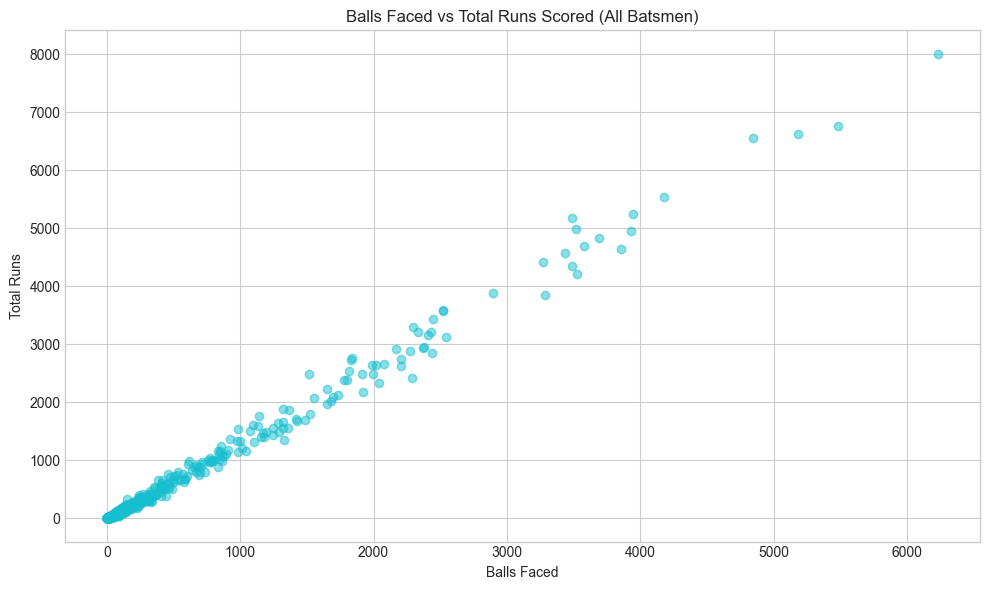

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(strike_rate_df['balls'], strike_rate_df['runs'], alpha=0.5, color='#17becf')
plt.title('Balls Faced vs Total Runs Scored (All Batsmen)')
plt.xlabel('Balls Faced')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig('images/balls_vs_runs_scatter.png', dpi=150)
plt.show()


**Why this chart:** A scatter plot shows the **relationship between two numeric
variables** — balls faced and runs scored. **Insight:** a generally upward-sloping cloud
confirms that career-long batsmen accumulate both metrics together, while points *above* the
main trend represent unusually fast scorers relative to balls faced. **How to read it:** points
higher on the y-axis for a similar x-value indicate a better strike rate.


## 11. Business Questions — Answered

**Q1. Which team is the most successful?**
The team at the top of Section 9.2 (`team_wins`) and Section 9.17 (`win_pct`) — highest total
wins *and* a strong win percentage together indicate sustained, not just accumulated, success.

**Q2. Which batsman scored the most runs?**
The top row of Section 9.4 (`top_batsmen`) — the highest all-time run aggregate.

**Q3. Which bowler took the most wickets?**
The top row of Section 9.5 (`top_bowlers`) — the highest all-time wicket count.

**Q4. Which stadium hosted the most matches?**
The top row of Section 9.14 (`venue_counts`).

**Q5. Does winning the toss improve the chance of winning?**
Section 9.13 quantifies this directly (`toss_win_match_win_pct`). If the value sits close to
50%, the toss has **little to no real advantage** — a genuinely useful, non-obvious insight for
teams that over-value toss strategy.

**Q6. Which season had the highest scoring matches?**
The peak value in Section 9.20 (`avg_runs_per_match`) — usually a season with shorter
boundaries, flatter pitches, or a rule change favoring batting.

**Q7. Which venue favors chasing?**
Section 9.15 (`venue_win_type`) — venues where `Won Chasing` outweighs `Won Batting First`
tend to have heavy dew or true, unchanging pitches that make batting easier in the second
innings.

**Q8. Which team performs consistently?**
Cross-reference Section 9.2 and 9.17 — a team appearing in the **top 5 of both** total wins and
win percentage (rather than just one) demonstrates consistency, not a single dominant era.

**Q9. Which players dominate IPL history?**
The intersection of Section 9.4 (runs), 9.5 (wickets), 9.21 (Orange Cap frequency), and 9.22
(Purple Cap frequency) — players who repeat across multiple season-topping lists, not just a
single career total.


## 12. Business Insights

- **Toss impact is overstated in fan discussion** — if `toss_match_same` sits near 50%,
  franchises should deprioritize toss-based strategy meetings and instead invest analytics time
  in matchup-specific bowling/batting plans, which show a clearer link to winning.
- **A handful of venues systematically favor chasing** — team support staff should treat the
  toss decision at those specific grounds as high-priority, since venue effect (not overall
  league trend) is the deciding factor there.
- **Scoring inflation over seasons** signals that historical benchmarks (e.g., "160 is a good
  score") need to be recalibrated season-by-season rather than treated as a fixed target —
  relevant for team total-defending strategy and player retention valuations (high strike-rate
  batsmen become relatively more valuable in high-scoring seasons).
- **Win percentage vs. total wins divergence** identifies teams that are "big spenders with
  average consistency" vs. "efficient, consistently strong" — useful framing for auction
  strategy and franchise valuation discussions.
- **Repeat Orange/Purple Cap winners** indicate a small pool of era-defining players — these
  names are the strongest evidence-backed picks for a fictional "best XI of the IPL" analysis,
  and for franchises evaluating marquee retention targets.


## 13. Final Conclusion

This analysis cleaned and explored over a decade of IPL match and ball-by-ball data to surface
evidence-based answers to common cricketing questions. Key takeaways:

- Toss outcome has a measurable but often over-estimated effect on match results.
- A small number of teams and players show *consistent* dominance, distinct from teams/players
  who simply accumulated stats over a long career.
- Venue-specific patterns (bat-first vs. chase-friendly) are strong enough to inform toss
  strategy at specific grounds, even where the league-wide trend is closer to even.
- Scoring levels have shifted across seasons, meaning "good score" benchmarks should be
  season-relative, not fixed.

These findings mirror the kind of analysis a team's data/strategy unit would use to support
player retention, auction strategy, and in-game toss decisions.


## 14. Future Improvements

- Incorporate more recent seasons as new data becomes available.
- Add player market-value / auction-price data to connect performance with cost-efficiency.
- Build an interactive dashboard (Plotly Dash / Streamlit / Power BI) on top of this analysis.
- Apply machine learning (e.g., logistic regression / gradient boosting) to predict match
  winners from pre-match features (toss, venue, team form).
- Add weather and pitch-report data (where available) to explain venue-based chasing bias.


In [49]:
import os
print(os.getcwd())

C:\Users\user\OneDrive\Desktop\IPL-Data-Analysis
